In [50]:
import cv2
import dlib
import numpy as np
from matplotlib import pyplot as plt
print(dlib.__version__)
plt.rcParams['figure.figsize'] = [15, 10]

19.24.6


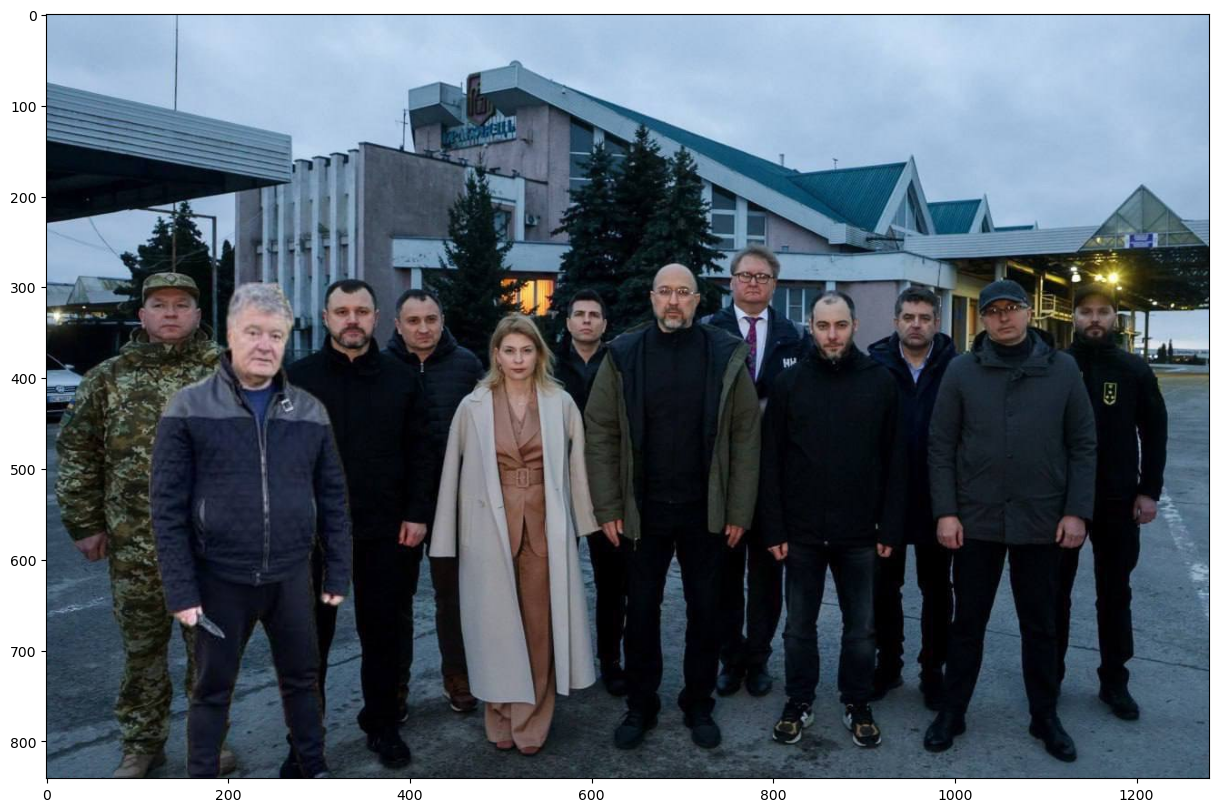

In [52]:
img = cv2.imread('faces.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

(<Axes: title={'center': 'Trained detection'}>,
 Text(0.5, 1.0, 'Trained detection'))

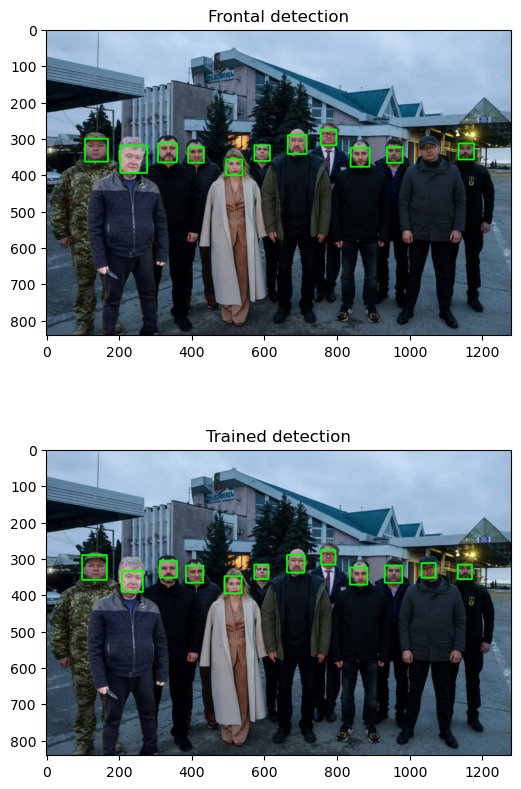

In [56]:
detector = dlib.get_frontal_face_detector()
cnn_detector = dlib.cnn_face_detection_model_v1("mmod_human_face_detector.dat")

# frontal detector
rects = detector(img, 1)
# print('frontal face detector : ', rects)

# trained model
cnn_rects = cnn_detector(img, 1)
# print('cnn_rects : ', cnn_rects)

# convert cnn denectors to rect
def cnn_detectors_to_cord(detectors):
    rects = []
    for i, d in enumerate(detectors):
        rects.append(d.rect)
    return rects

# draw rect on image
def draw_detected(rects, imgCopy):
    for r in rects:
        x1, y1, x2, y2 = r.left(), r.top(), r.right(), r.bottom()
        cv2.rectangle(imgCopy, (x1, y1), (x2, y2), (0, 255, 0), 3)
    return imgCopy


# detection algo results
faces = draw_detected(rects, np.copy(img))

# trained result
cnn_rects = cnn_detectors_to_cord(cnn_rects)
cnn_faces = draw_detected(cnn_rects, np.copy(img))

plt.figure(figsize=(6, 10))
plt.subplot(211), plt.imshow(faces), plt.title('Frontal detection')
plt.subplot(212), plt.imshow(cnn_faces), plt.title('Trained detection')


# The frontal recognition algorithm was unable to recognize the second person on the right wearing glasses and a hat.
# However, the trained model was able to do so, but it took much longer.